In [19]:
import re
import os
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=100000)
plt.rcParams.update({'font.size': 20})
HTR2EV = 27.21139

def re_int(string_sub, string_search):
    return int(re.sub(string_sub, '', re.search(r'%s\d+' % (string_sub), string_search).group()))

def re_float(string_sub, string_search):
    return float(re.sub(string_sub, '', re.search(r'%s[-]?\d+[.]\d+' % (string_sub), string_search).group()))

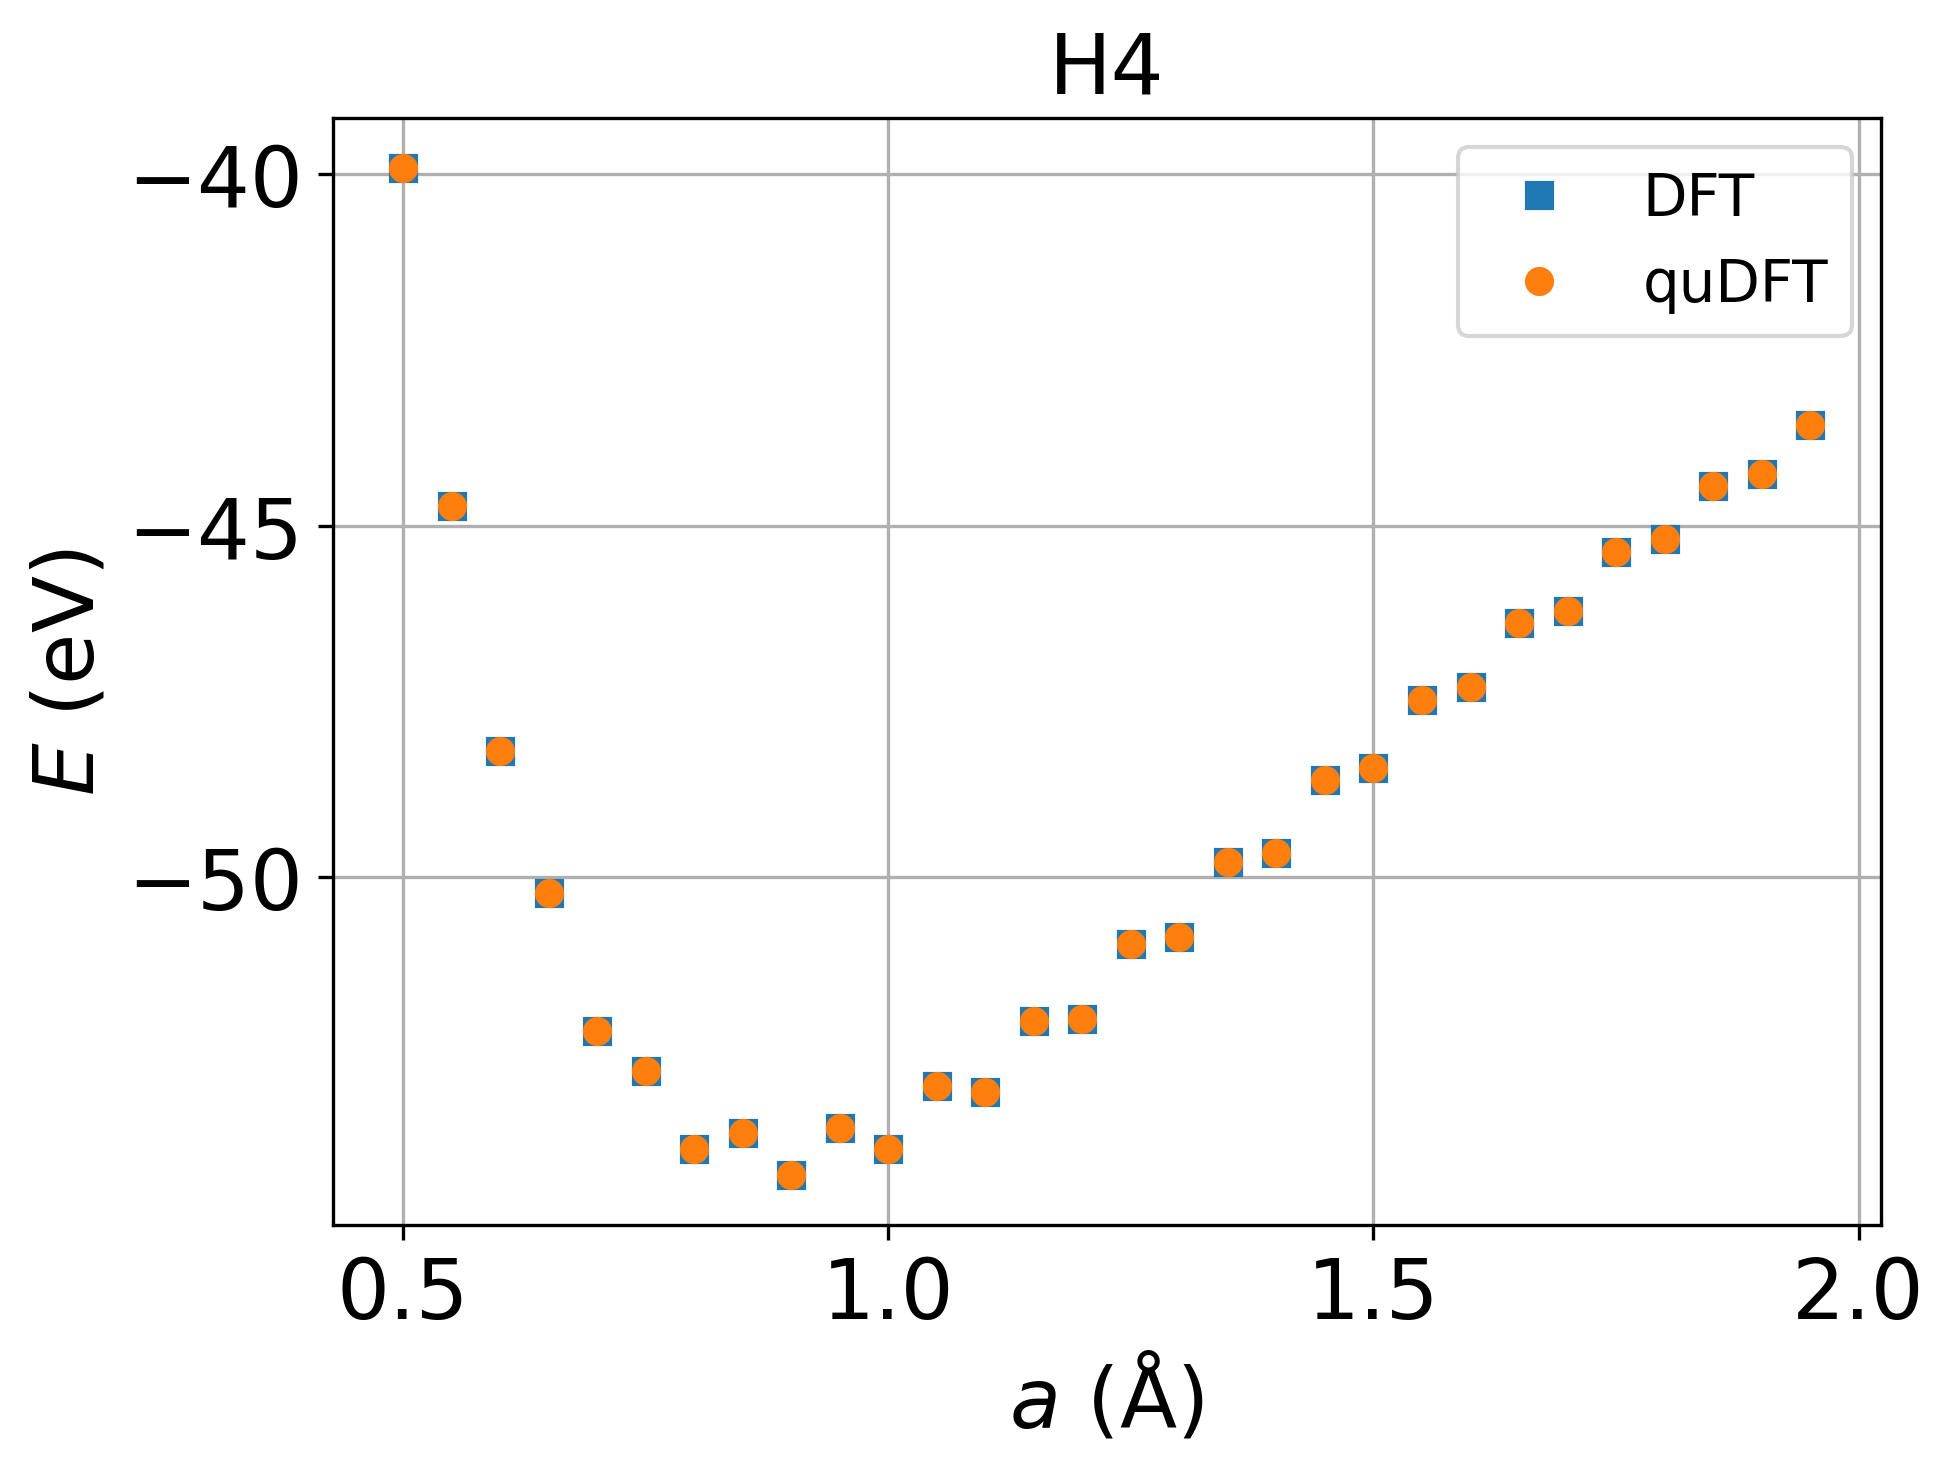

In [55]:
def show_E_a(system='H4', method=['dft', 'qdftv1', 'qdftv2']):
    method_dict = {
        'dft': 'DFT',
        'qdftv1': 'QDFT',
        'qdftv2': 'quDFT',
    }
    marker = ['s', 'o', '^']
    linestyle=['none', 'none', 'none']

    data = []
    for i, m in enumerate(method):
        data_i = []
        for fn in [fn for fn in os.listdir('output') if re.match(system, fn)]:
            a = re_float('a', fn)
            with open(f'output/{fn}/{m}.etot', 'r') as f: e = f.read()
            data_i.append([a, float(e)])
        data_i = np.array(data_i)
        data.append(data_i[data_i[:, 0].argsort()])

    fig, ax = plt.subplots(constrained_layout=True, dpi=300)
    for d, m, mk, ls in zip(data, method, marker, linestyle):
        ax.plot(d[:-1, 0], d[:-1, 1] * HTR2EV, marker=mk, linestyle=ls, label=f'{method_dict[m]}')
    ax.set_xlabel(r'$a$ (Å)')
    ax.set_ylabel(r'$E$ (eV)')
    ax.set_title(re.sub('_', ' ', f'{system}'), fontsize='medium')
    ax.legend(fontsize='x-small')
    ax.grid(True)
    plt.savefig(f'fig/{system}_{'_'.join(method)}.png')
    plt.show()
    
show_E_a(system='H4', method=['dft', 'qdftv2'])

[[   2.          -48.714585    366.42052031]
 [   3.          -48.935622    337.78718615]
 [   4.          -48.625916   1418.20803022]
 [   5.          -49.04031     639.78922772]
 [   6.          -48.826402    825.1720531 ]]


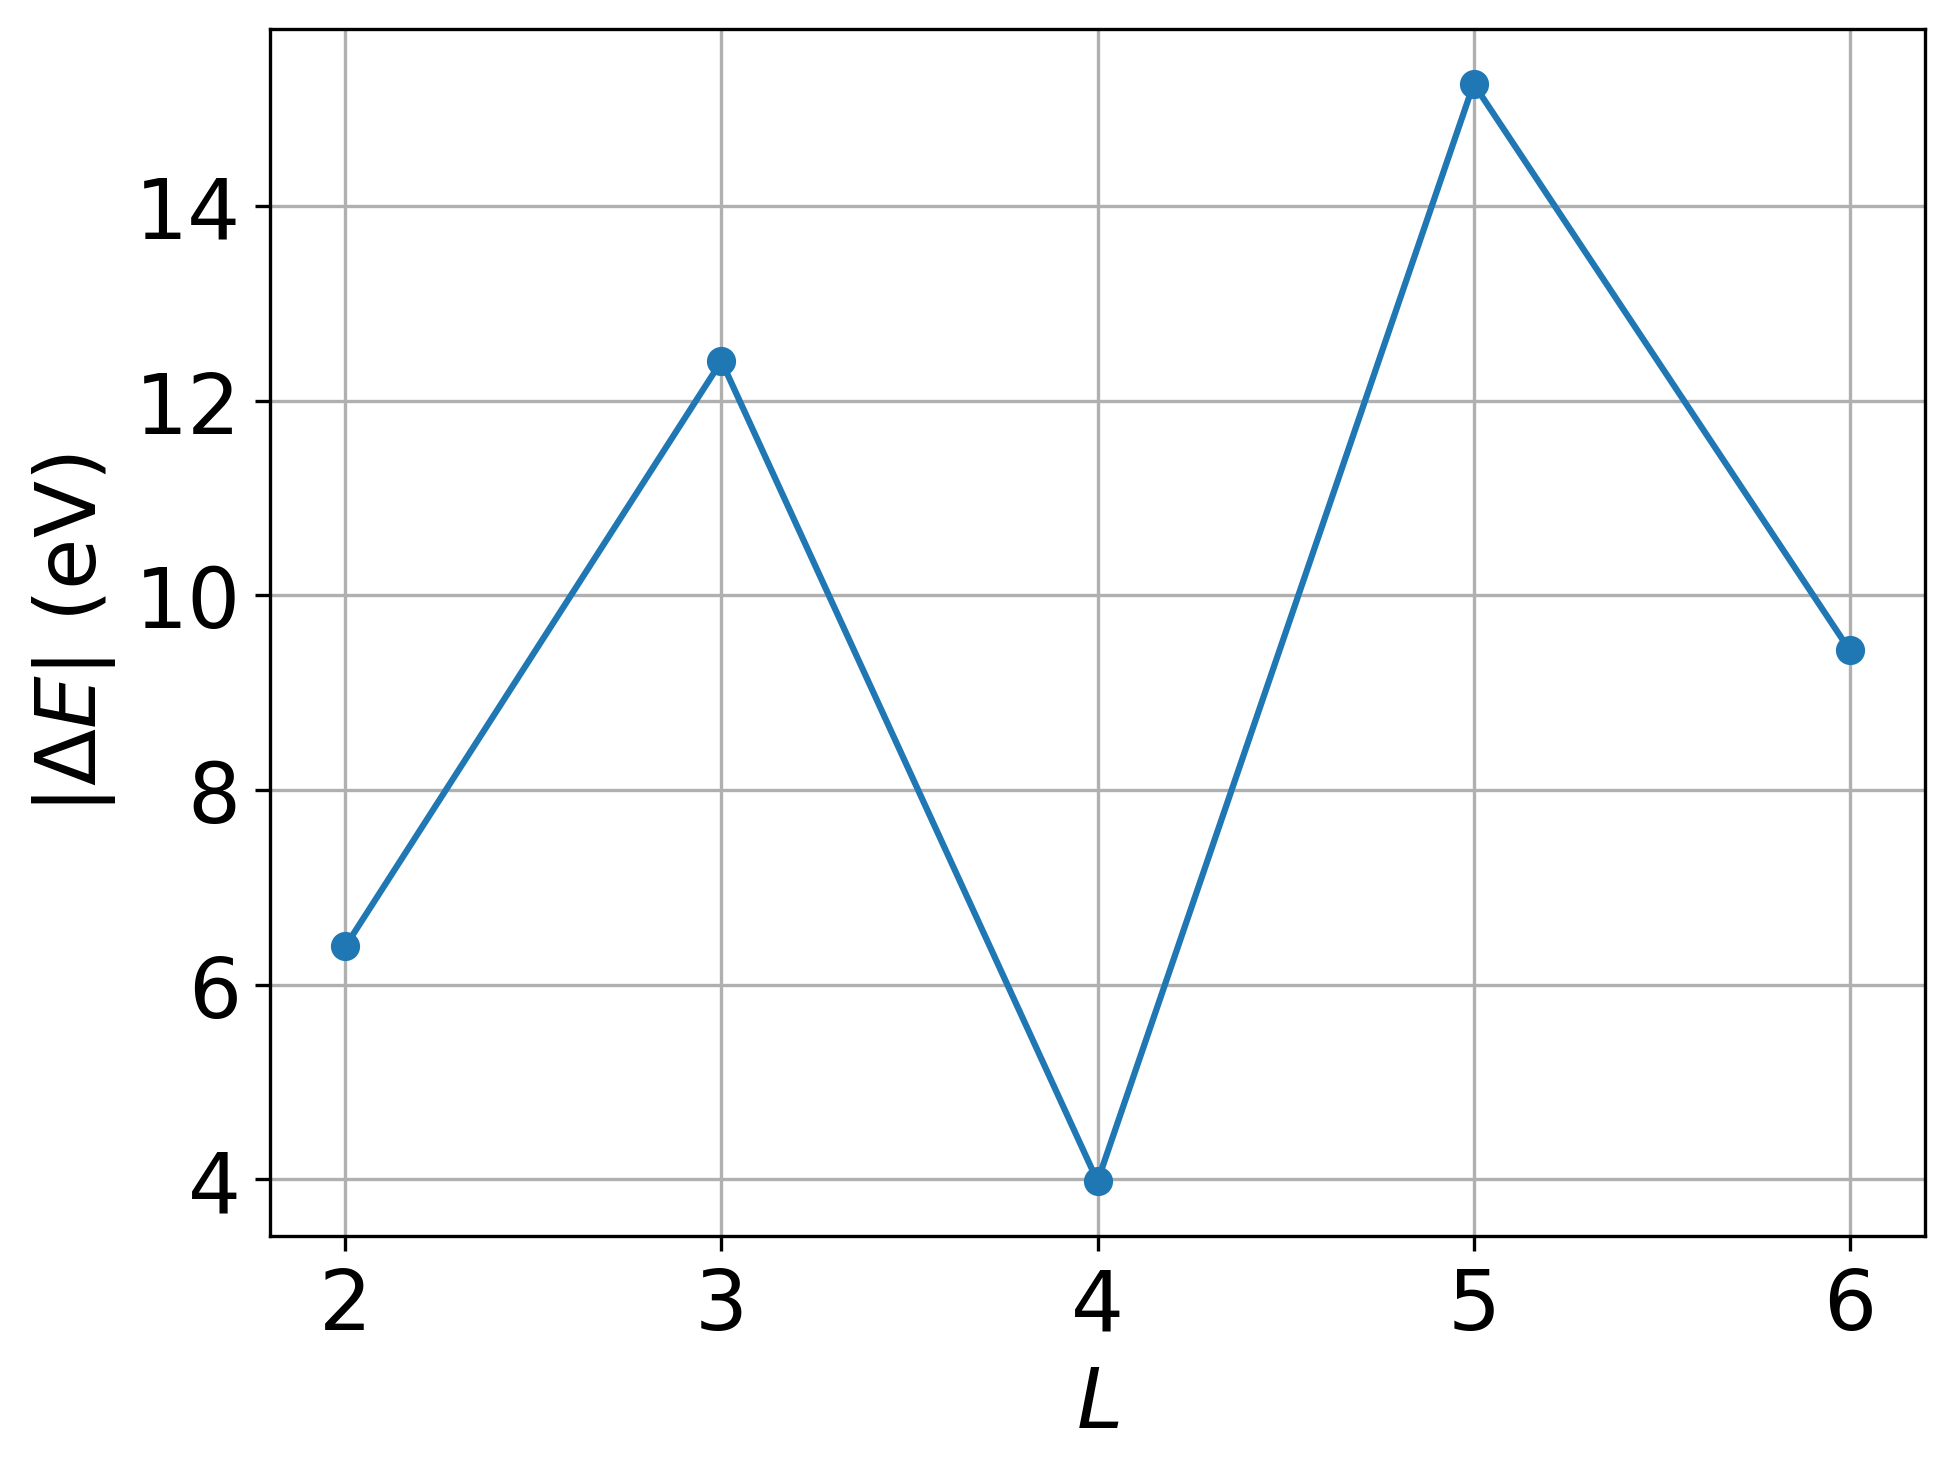

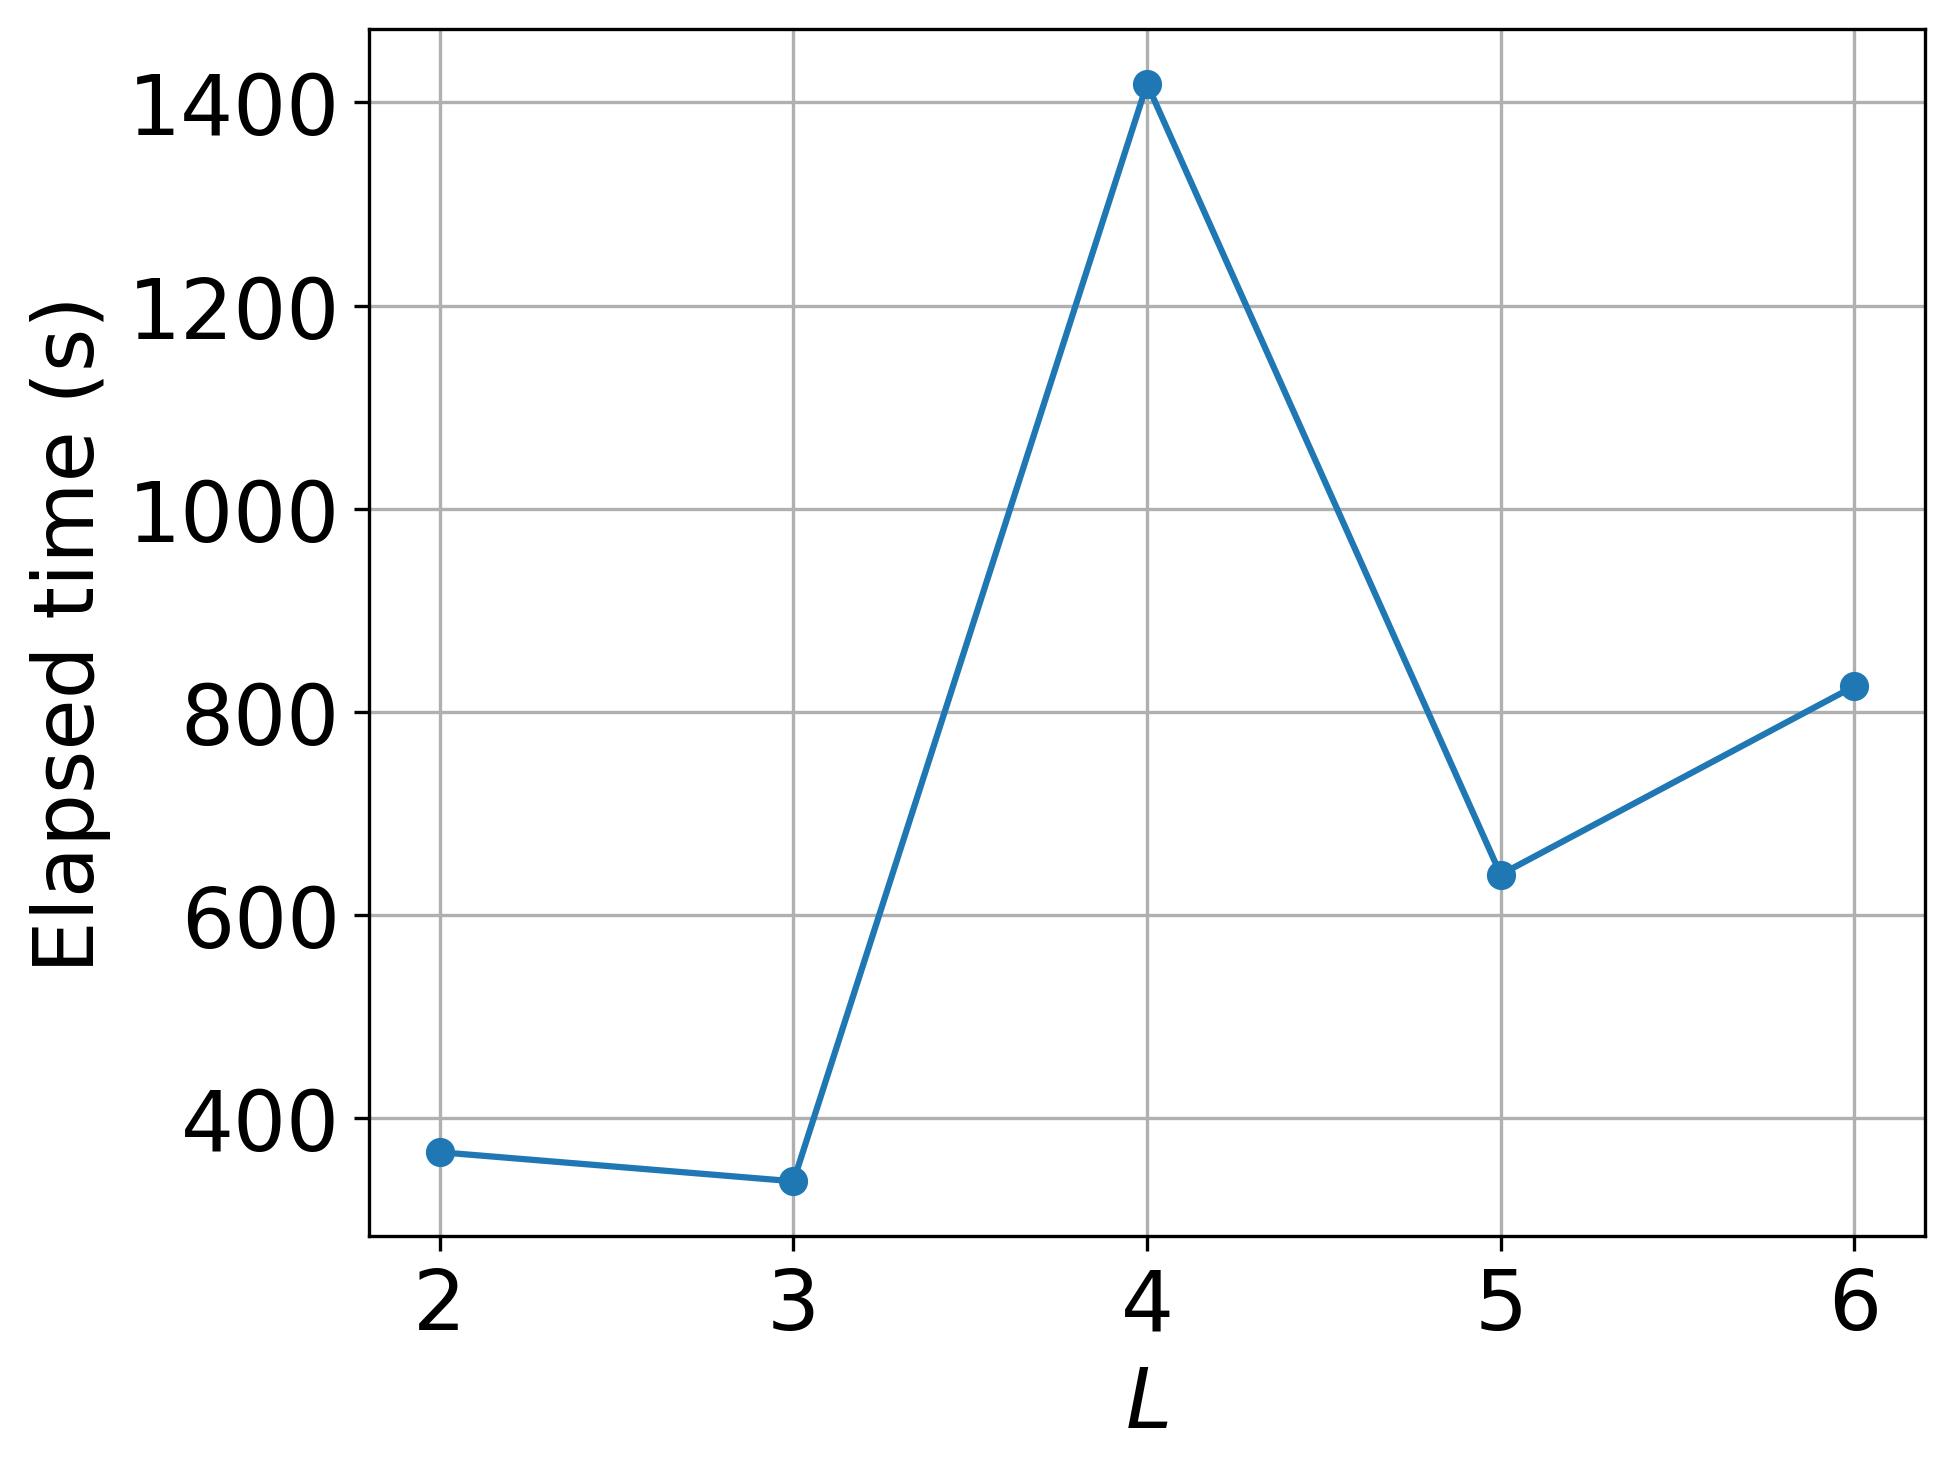

In [52]:
def show_E_L(system='H4_a1.00_qdftv2', e_target=0.):
    method_dict = {
        'dft': 'DFT',
        'qdftv1': 'QDFT_original',
        'qdftv2': 'QDFT',
    }

    data = []
    for fn in [fn for fn in os.listdir('log') if re.match(system, fn)]:
        L = re_int('L', fn)
        with open(f'log/{fn}', 'r') as f: e, t = f.read().split()
        data.append([L, float(e), float(t)])
    data = np.array(data)
    data = data[data[:, 0].argsort()]
    print(data)

    fig, ax = plt.subplots(constrained_layout=True, dpi=300)
    ax.plot(data[:, 0], abs(data[:, 1] - e_target) * HTR2EV, marker='o')
    ax.set_xlabel(r'$L$')
    ax.set_ylabel(r'$|\Delta E|$ (eV)')
    #ax.set_title(system, fontsize='medium')
    #ax.legend(fontsize='x-small')
    #ax.set_ylim([-0.001, 0.001])
    ax.grid(True)
    plt.savefig(f'fig/{system}_elog.png')
    plt.show()
    
    fig, ax = plt.subplots(constrained_layout=True, dpi=300)
    ax.plot(data[:, 0], data[:, 2], marker='o')
    ax.set_xlabel(r'$L$')
    ax.set_ylabel('Elapsed time (s)')
    ax.grid(True)
    plt.savefig(f'fig/{system}_tlog.png')
    plt.show()
    
show_E_L('Cu_a3.58_qdftv2', e_target=-48.479726)